In [1]:
import Pkg
Pkg.activate(temp=true)
Pkg.add(["FFTW", "Optim", "OrdinaryDiffEq", "ProgressMeter", "Plots", "StaticArrays"])

  Activating new project at `C:\Users\kiril\AppData\Local\Temp\jl_lpWywH`
   Resolving package versions...
    Updating `C:\Users\kiril\AppData\Local\Temp\jl_lpWywH\Project.toml`
  [7a1cc6ca] + FFTW v1.10.0
  [429524aa] + Optim v2.0.1
  [1dea7af3] + OrdinaryDiffEq v6.111.0
  [91a5bcdd] + Plots v1.41.6
  [92933f4c] + ProgressMeter v1.11.0
  [90137ffa] + StaticArrays v1.9.18
    Updating `C:\Users\kiril\AppData\Local\Temp\jl_lpWywH\Manifest.toml`
  [47edcb42] + ADTypes v1.21.0
  [621f4979] + AbstractFFTs v1.5.0
  [7d9f7c33] + Accessors v0.1.44
  [79e6a3ab] + Adapt v4.5.0
  [66dad0bd] + AliasTables v1.1.3
  [4fba245c] + ArrayInterface v7.23.0
  [d1d4a3ce] + BitFlags v0.1.9
  [62783981] + BitTwiddlingConvenienceFunctions v0.1.6
  [70df07ce] + BracketingNonlinearSolve v1.12.0
  [2a0fbf3d] + CPUSummary v0.2.7
  [fb6a15b2] + CloseOpenIntervals v0.1.13
  [944b1d66] + CodecZlib v0.7.8
  [35d6a980] + ColorSchemes v3.31.0
  [3da002f7] + ColorTypes v0.12.1
  [c3611d14] + ColorVectorSpace v0.11.0
 

  [6e34b625] + Bzip2_jll v1.0.9+0
  [83423d85] + Cairo_jll v1.18.6+0
  [ee1fde0b] + Dbus_jll v1.16.2+0
  [2702e6a9] + EpollShim_jll v0.0.20230411+1
  [2e619515] + Expat_jll v2.7.3+0
  [b22a6f82] + FFMPEG_jll v8.0.1+1
  [f5851436] + FFTW_jll v3.3.11+0
  [a3f928ae] + Fontconfig_jll v2.17.1+0
  [d7e528f0] + FreeType2_jll v2.14.3+1
  [559328eb] + FriBidi_jll v1.0.17+0
  [0656b61e] + GLFW_jll v3.4.1+0
  [d2c73de3] + GR_jll v0.73.24+0
⌅ [b0724c58] + GettextRuntime_jll v0.22.4+0
  [61579ee1] + Ghostscript_jll v9.55.1+0
  [7746bdde] + Glib_jll v2.86.3+0
  [3b182d85] + Graphite2_jll v1.3.15+0
  [2e76f6c2] + HarfBuzz_jll v8.5.1+0
  [1d5cc7b8] + IntelOpenMP_jll v2025.2.0+0
  [aacddb02] + JpegTurbo_jll v3.1.4+0
  [c1c5ebd0] + LAME_jll v3.100.3+0
  [88015f11] + LERC_jll v4.0.1+0
  [1d63c593] + LLVMOpenMP_jll v18.1.8+0
⌅ [e9f186c6] + Libffi_jll v3.4.7+0
  [7e76a0d4] + Libglvnd_jll v1.7.1+1
  [94ce4f54] + Libiconv_jll v1.18.0+0
  [4b2f31a3] + Libmount_jll v2.41.3+0
  [89763e89] + Libtiff_jll v4.7.2+0

In [2]:
using LinearAlgebra
using Statistics
using FFTW
using Optim
using OrdinaryDiffEq
using ProgressMeter
using Plots
using StaticArrays
using Printf
using Base.Threads: @threads, nthreads

gr()

Plots.GRBackend()

In [97]:
const PHI0 = 6.62607015e-34 / (2.0 * 1.602176634e-19)
const PHI_SCALE = PHI0 / (2.0 * π)
const C2 = ComplexF64
const M2 = SMatrix{2,2,C2,4}
const V2 = SVector{2,C2}

# ---------------- settings ----------------
alpha_snail = 0.12
Ic_big = 2.7e-6
C_big = 80e-15
C_snail_eff = alpha_snail * C_big + C_big / 3.0

N_cells = 912
Z_port = 50.0
C_ground_per_cell = 80e-15
L_geometric_per_cell = 0.0e-12

USE_FIELD_GRADIENT = true
EDGE_RELATIVE_FIELD = -0.15  # linear V-profile: edge field = center field * (1 + EDGE_RELATIVE_FIELD)

USE_DISSIPATION = true
CELL_QI = 65.0               # effective internal Q of one cell near its local plasma resonance; smaller Q = stronger linear loss

# Time-domain amplitude readout.
TD_MEASURE_MODE = :fftbin    # :fftbin = old nearest-bin FFT, :lockin = complex projection at f_signal, :hilbert = band-pass + Hilbert envelope
HILBERT_BW = 0.35e9          # full band for :hilbert around f_signal

# Extra gain-limiting physics used only in the reduced HB gain-map model.
HB_USE_ZPROP_PUMP = true       # true = launch the pump into the full line and solve its z-dependent profile; false = use one uniform pump phase drop in every cell
HB_USE_NL_PUMP_PROP = true     # true = iterate the pump profile with pump-induced stiffness shift (self-Kerr on the pump); false = linear pump propagation only
HB_USE_PUMP_DEPLETION = false  # true = feed signal/idler conversion back as cumulative distributed pump loading; false = undepleted pump
HB_USE_HARMONIC_LEAKAGE = true # true = add pump-amplitude-dependent extra conductance for power leaking into harmonics / sidebands not kept in the 2-tone HB block

HB_PUMP_ITERS = 4
HB_DEPLETION_ITERS = 3
HB_PUMP_RELAX = 0.55
HB_LEAKAGE_K = 0.8
HB_DEPLETION_K = 1.2

HB_USE_NL_SELECTIVE_LOSS = true # true = make HB-only extra loss stronger in cells where the local SNAIL nonlinearity is larger; false = use the same HB extra loss in every cell
HB_NLLOSS_K = 1.4               # strength of the nonlinearity-weighted multiplier applied to HB leakage and depletion
HB_NLLOSS_I2_WEIGHT = 1.0       # weight of |i2| (3WM coefficient) in the local HB loss multiplier
HB_NLLOSS_I3_WEIGHT = 1.0      # weight of |i3| (4WM / self-Kerr coefficient) in the local HB loss multiplier
HB_NLLOSS_POWER = 1.0           # >1 makes the extra HB loss more selective to the most nonlinear cells

LOOKUP_POINTS = 6001
USE_THREADS = nthreads() > 1

RUN_S21_MAP = true
flux_center_frustration = collect(range(0.0, 7.0, length=1001))
freq_array = collect(range(4.0e9, 8.0e9, length=401))

RUN_TIME_DOMAIN_TWPA = true
time_domain_fluxes = [0.42]
signal_frequency = 6.0e9
LOCK_PUMP_TO_2X_SIGNAL = true
pump_frequency_manual = 12.0e9
pump_frequency = LOCK_PUMP_TO_2X_SIGNAL ? 2.0 * signal_frequency : pump_frequency_manual
pump_power_dBm = -60.0
signal_amplitude_uV = 0.05
pump_turn_on_time = 3.0e-9
signal_turn_on_time = 6.0e-9
turn_on_smoothing = 0.4e-9
t_final = 40.0e-9
n_time_points = 2001
max_step = 50.0e-12
fft_start_time = 20.0e-9
time_domain_reltol = 1e-6
time_domain_abstol = 1e-9

RUN_GAIN_MAP = true
gain_map_flux_scan = collect(range(0.0, 7.0, length=101))
pump_power_scan_dBm = collect(range(-70.0, -50.0, length=21))
gain_map_signal_freqs = collect(range(4.0e9, 8.0e9, length=10))
pump_frequency_for_gain_map = 12.0e9
signal_average_mode = :dB  # :dB or :linear

gain_map_vmin_dB = -25.0
gain_map_vmax_dB = 10.0
threewm_sweet_spot_fluxes = Float64[]

Float64[]

In [98]:
# ---------------- small helpers ----------------
dbm_to_watts(p_dbm) = 1e-3 * 10.0^(p_dbm / 10.0)
dbm_to_vrms(p_dbm; z0=50.0) = sqrt(dbm_to_watts(p_dbm) * z0)
dbm_to_vpeak(p_dbm; z0=50.0) = sqrt(2.0) * dbm_to_vrms(p_dbm; z0=z0)
uv_to_v(a_uV) = a_uV * 1e-6
safe_gain_db(g) = 20.0 * log10(max(g, 1e-30))
finite_mean(v) = begin w = v[.!isnan.(v)]; isempty(w) ? NaN : mean(w) end

# ---------------- device bundle ----------------
struct DeviceParams
    alpha_snail::Float64
    Ic_big::Float64
    C_snail_eff::Float64
    N_cells::Int
    Z_port::Float64
    C_ground_per_cell::Float64
    L_geometric_per_cell::Float64
end

make_device() = DeviceParams(alpha_snail, Ic_big, C_snail_eff, N_cells, Z_port, C_ground_per_cell, L_geometric_per_cell)

# ---------------- SNAIL ----------------
@inline snail_potential(δ, φ, α) = -α * cos(δ) - 3.0 * cos((φ - δ) / 3.0)
@inline snail_current(δ, φ, α, Ic) = α * Ic * sin(δ) - Ic * sin((φ - δ) / 3.0)
@inline snail_i1(δ, φ, α, Ic) = α * Ic * cos(δ) + (Ic / 3.0) * cos((φ - δ) / 3.0)
@inline snail_i2(δ, φ, α, Ic) = -α * Ic * sin(δ) + (Ic / 9.0) * sin((φ - δ) / 3.0)
@inline snail_i3(δ, φ, α, Ic) = -α * Ic * cos(δ) - (Ic / 27.0) * cos((φ - δ) / 3.0)

# ---------------- linear field gradient ----------------
function local_scale_vector(n_cells::Int)
    !USE_FIELD_GRADIENT && return ones(Float64, n_cells)
    x = range(-1.0, 1.0, length=n_cells)
    return 1.0 .+ EDGE_RELATIVE_FIELD .* abs.(x)
end

function get_local_flux_profile(flux_center::AbstractVector{<:Real}, n_cells::Int)
    s = local_scale_vector(n_cells)
    out = Matrix{Float64}(undef, n_cells, length(flux_center))
    @inbounds for j in eachindex(flux_center), n in 1:n_cells
        out[n, j] = s[n] * flux_center[j]
    end
    return out, s
end

function get_local_flux_profile(flux_center::Real, n_cells::Int)
    s = local_scale_vector(n_cells)
    out = similar(s)
    @inbounds for n in eachindex(s)
        out[n] = s[n] * flux_center
    end
    return out, s
end

get_local_flux_profile (generic function with 2 methods)

In [99]:
# ---------------- lookup ----------------
struct SnailLookup
    flux_min::Float64
    flux_step::Float64
    delta0::Vector{Float64}
    i1::Vector{Float64}
    i2::Vector{Float64}
    i3::Vector{Float64}
    i2_ref::Float64
    i3_ref::Float64
end

function build_snail_lookup(flux_min::Float64, flux_max::Float64, n_pts::Int, α::Float64, Ic::Float64)
    flux_grid = collect(range(flux_min, flux_max, length=n_pts))
    phi_grid = 2π .* flux_grid
    delta0 = zeros(Float64, n_pts)

    coarse = collect(range(-4π, 4π, length=12001))
    U0 = [snail_potential(x, phi_grid[1], α) for x in coarse]
    delta0[1] = coarse[argmin(U0)]

    prog = Progress(n_pts - 1; desc="SNAIL lookup", showspeed=true)
    for k in 2:n_pts
        prev = delta0[k - 1]
        best_x, best_u = prev, Inf
        for shift in (-2π, 0.0, 2π)
            left = prev + shift - 1.2π
            right = prev + shift + 1.2π
            res = optimize(x -> snail_potential(x, phi_grid[k], α), left, right, Brent())
            u = Optim.minimum(res)
            x = Optim.minimizer(res)
            if u < best_u
                best_u, best_x = u, x
            end
        end
        delta0[k] = best_x
        next!(prog)
    end

    i1 = similar(delta0)
    i2 = similar(delta0)
    i3 = similar(delta0)
    @inbounds for k in eachindex(delta0)
        i1[k] = snail_i1(delta0[k], phi_grid[k], α, Ic)
        i2[k] = snail_i2(delta0[k], phi_grid[k], α, Ic)
        i3[k] = snail_i3(delta0[k], phi_grid[k], α, Ic)
    end
    i2_ref = max(maximum(abs.(i2)), 1e-30)
    i3_ref = max(maximum(abs.(i3)), 1e-30)
    return SnailLookup(flux_min, (flux_max - flux_min) / (n_pts - 1), delta0, i1, i2, i3, i2_ref, i3_ref)
end

@inline function lookup_eval(lookup::SnailLookup, flux::Float64)
    n = length(lookup.delta0)
    x = clamp((flux - lookup.flux_min) / lookup.flux_step, 0.0, (n - 1) - 1e-12)
    i = min(Int(floor(x)) + 1, n - 1)
    w = x - (i - 1)
    δ0 = (1 - w) * lookup.delta0[i] + w * lookup.delta0[i + 1]
    i1 = (1 - w) * lookup.i1[i] + w * lookup.i1[i + 1]
    i2 = (1 - w) * lookup.i2[i] + w * lookup.i2[i + 1]
    i3 = (1 - w) * lookup.i3[i] + w * lookup.i3[i + 1]
    return δ0, i1, i2, i3
end

function build_lookup_from_scans(all_flux::Vector{Float64}, device::DeviceParams)
    s = local_scale_vector(device.N_cells)
    fmin = minimum(all_flux) * minimum(s)
    fmax = maximum(all_flux) * maximum(s)
    span = max(fmax - fmin, 1.0)
    return build_snail_lookup(fmin - 0.02 * span, fmax + 0.02 * span, LOOKUP_POINTS, device.alpha_snail, device.Ic_big)
end

# ---------------- static state ----------------
struct StaticState
    phi_center::Float64
    local_flux::Vector{Float64}
    local_scale::Vector{Float64}
    local_phi_ext::Vector{Float64}
    delta0::Vector{Float64}
    i1::Vector{Float64}
    i2::Vector{Float64}
    i3::Vector{Float64}
    nlw::Vector{Float64}
    Lcell::Vector{Float64}
    G0::Vector{Float64}
    static_phase::Vector{Float64}
end

@inline function loss_conductance(L::Float64, C::Float64)
    if !USE_DISSIPATION || !isfinite(CELL_QI) || CELL_QI <= 0
        return 0.0
    end
    return 1.0 / (CELL_QI * sqrt(L / C))
end

@inline function nl_selective_weight(i2::Float64, i3::Float64, lookup::SnailLookup)
    !HB_USE_NL_SELECTIVE_LOSS && return 1.0
    wsum = HB_NLLOSS_I2_WEIGHT + HB_NLLOSS_I3_WEIGHT
    wsum <= 0 && return 1.0
    a2 = abs(i2) / max(lookup.i2_ref, 1e-30)
    a3 = abs(i3) / max(lookup.i3_ref, 1e-30)
    mix = clamp((HB_NLLOSS_I2_WEIGHT * a2 + HB_NLLOSS_I3_WEIGHT * a3) / wsum, 0.0, 3.0)
    return 1.0 + HB_NLLOSS_K * mix^HB_NLLOSS_POWER
end

function prepare_static_state(phi_center::Float64, lookup::SnailLookup, device::DeviceParams)
    local_flux, local_scale = get_local_flux_profile(phi_center, device.N_cells)
    local_phi_ext = 2π .* local_flux
    delta0 = zeros(Float64, device.N_cells)
    i1 = zeros(Float64, device.N_cells)
    i2 = zeros(Float64, device.N_cells)
    i3 = zeros(Float64, device.N_cells)
    nlw = zeros(Float64, device.N_cells)
    Lcell = zeros(Float64, device.N_cells)
    G0 = zeros(Float64, device.N_cells)

    @inbounds for n in 1:device.N_cells
        δ0, d1, d2, d3 = lookup_eval(lookup, local_flux[n])
        delta0[n] = δ0
        i1[n] = d1
        i2[n] = d2
        i3[n] = d3
        nlw[n] = nl_selective_weight(d2, d3, lookup)
        Lcell[n] = PHI_SCALE / max(d1, 1e-30) + device.L_geometric_per_cell
        G0[n] = loss_conductance(Lcell[n], device.C_snail_eff)
    end

    static_phase = zeros(Float64, device.N_cells + 1)
    @inbounds for n in 2:length(static_phase)
        static_phase[n] = static_phase[n - 1] - delta0[n - 1]
    end
    return StaticState(phi_center, local_flux, local_scale, local_phi_ext, delta0, i1, i2, i3, nlw, Lcell, G0, static_phase)
end

function prepare_static_states(flux_scan::Vector{Float64}, lookup::SnailLookup, device::DeviceParams)
    states = Vector{StaticState}(undef, length(flux_scan))
    prog = Progress(length(flux_scan); desc="Static states", showspeed=true)
    if USE_THREADS
        lk = ReentrantLock()
        @threads for j in eachindex(flux_scan)
            states[j] = prepare_static_state(flux_scan[j], lookup, device)
            lock(lk) do
                next!(prog)
            end
        end
    else
        for j in eachindex(flux_scan)
            states[j] = prepare_static_state(flux_scan[j], lookup, device)
            next!(prog)
        end
    end
    return states
end

prepare_static_states (generic function with 1 method)

In [100]:
# ---------------- S21 ----------------
@inline branch_impedance(L::Float64, G::Float64, ω::Float64, Cb::Float64) = inv(G + inv(im * ω * L) + im * ω * Cb)

function compute_s21_for_state(state::StaticState, ω_array::Vector{Float64}, device::DeviceParams)
    out = Vector{ComplexF64}(undef, length(ω_array))
    @inbounds for fi in eachindex(ω_array)
        ω = ω_array[fi]
        Ysh = im * ω * device.C_ground_per_cell
        A, B, C, D = 1.0 + 0im, 0.0 + 0im, 0.0 + 0im, 1.0 + 0im
        for n in 1:device.N_cells
            Z = branch_impedance(state.Lcell[n], state.G0[n], ω, device.C_snail_eff)
            Ac = 1.0 + 0.5 * Z * Ysh
            Bc = Z
            Cc = Ysh * (1.0 + 0.25 * Z * Ysh)
            Dc = Ac
            A, B, C, D = A * Ac + B * Cc, A * Bc + B * Dc, C * Ac + D * Cc, C * Bc + D * Dc
        end
        out[fi] = 2.0 / (A + B / device.Z_port + C * device.Z_port + D)
    end
    return out
end

function compute_s21_map(flux_scan::Vector{Float64}, freq_array::Vector{Float64}, lookup::SnailLookup, device::DeviceParams)
    ω_array = 2π .* freq_array
    states = prepare_static_states(flux_scan, lookup, device)
    S21 = Matrix{ComplexF64}(undef, length(freq_array), length(flux_scan))
    prog = Progress(length(flux_scan); desc="S21 map", showspeed=true)
    if USE_THREADS
        lk = ReentrantLock()
        @threads for j in eachindex(flux_scan)
            S21[:, j] = compute_s21_for_state(states[j], ω_array, device)
            lock(lk) do
                next!(prog; showvalues=[(:flux, @sprintf("%.4f", flux_scan[j]))])
            end
        end
    else
        for j in eachindex(flux_scan)
            S21[:, j] = compute_s21_for_state(states[j], ω_array, device)
            next!(prog; showvalues=[(:flux, @sprintf("%.4f", flux_scan[j]))])
        end
    end
    return S21, 20.0 .* log10.(max.(abs.(S21), 1e-30)), states
end

function plot_s21_map(flux_scan, freq_array, S21_dB, local_scale)
    p = heatmap(flux_scan, freq_array ./ 1e9, S21_dB;
        xlabel="External magnetic flux [Φ/Φ₀]", ylabel="Frequency (GHz)",
        title="S21 map" * (USE_DISSIPATION ? @sprintf(", Q = %.1f", CELL_QI) : ""),
        colorbar_title="S21 (dB)", c=:viridis, size=(950, 700))
    display(p)
    if USE_FIELD_GRADIENT
        display(plot(1:length(local_scale), local_scale; lw=2, xlabel="Cell index", ylabel="Local field / center field",
            title="Linear magnetic-field profile", legend=false, size=(800, 320)))
    end
end

plot_s21_map (generic function with 1 method)

In [101]:
# ---------------- time domain ----------------
function build_capacitance_factor(device::DeviceParams)
    n = device.N_cells + 1
    d = fill(device.C_ground_per_cell + 2.0 * device.C_snail_eff, n)
    d[1] = device.C_ground_per_cell + device.C_snail_eff
    d[end] = device.C_ground_per_cell + device.C_snail_eff
    e = fill(-device.C_snail_eff, n - 1)
    return ldlt(SymTridiagonal(d, e))
end

smooth_step(t, t0, τ) = 0.5 * (1.0 + tanh((t - t0) / τ))

struct DriveSpec
    pump_frequency::Float64
    signal_frequency::Float64
    pump_amplitude_V::Float64
    signal_amplitude_V::Float64
    pump_turn_on_time::Float64
    signal_turn_on_time::Float64
    smoothing_time::Float64
    pump_on::Bool
    signal_on::Bool
end

@inline function drive_voltage(d::DriveSpec, t::Float64)
    v = 0.0
    if d.pump_on
        v += d.pump_amplitude_V * smooth_step(t, d.pump_turn_on_time, d.smoothing_time) * cos(2π * d.pump_frequency * t)
    end
    if d.signal_on
        v += d.signal_amplitude_V * smooth_step(t, d.signal_turn_on_time, d.smoothing_time) * cos(2π * d.signal_frequency * t)
    end
    return v
end

mutable struct TDContext{F}
    n_nodes::Int
    local_phi_ext::Vector{Float64}
    g_branch::Vector{Float64}
    cap_factor::F
    alpha_snail::Float64
    Ic_big::Float64
    Z_port::Float64
    drive::DriveSpec
    delta::Vector{Float64}
    i_branch::Vector{Float64}
    rhs_current::Vector{Float64}
    phase_ddot::Vector{Float64}
    node_voltage::Vector{Float64}
end

function TDContext(state::StaticState, drive::DriveSpec, cap_factor::F, device::DeviceParams) where {F}
    n_nodes = device.N_cells + 1
    return TDContext{F}(
        n_nodes,
        copy(state.local_phi_ext),
        copy(state.G0),
        cap_factor,
        device.alpha_snail,
        device.Ic_big,
        device.Z_port,
        drive,
        zeros(Float64, device.N_cells),
        zeros(Float64, device.N_cells),
        zeros(Float64, n_nodes),
        zeros(Float64, n_nodes),
        zeros(Float64, n_nodes),
    )
end

function td_rhs!(du, u, ctx::TDContext, t)
    n = ctx.n_nodes
    phase = @view u[1:n]
    phase_dot = @view u[n + 1:2 * n]

    @inbounds for k in 1:(n - 1)
        δ = phase[k] - phase[k + 1]
        vδ = PHI_SCALE * (phase_dot[k] - phase_dot[k + 1])
        ctx.delta[k] = δ
        ctx.i_branch[k] = snail_current(δ, ctx.local_phi_ext[k], ctx.alpha_snail, ctx.Ic_big) + ctx.g_branch[k] * vδ
    end

    fill!(ctx.rhs_current, 0.0)
    ctx.rhs_current[1] -= ctx.i_branch[1]
    @inbounds for k in 2:(n - 1)
        ctx.rhs_current[k] += ctx.i_branch[k - 1] - ctx.i_branch[k]
    end
    ctx.rhs_current[n] += ctx.i_branch[end]

    @inbounds for k in 1:n
        ctx.node_voltage[k] = PHI_SCALE * phase_dot[k]
    end
    ctx.rhs_current[1] += (drive_voltage(ctx.drive, t) - ctx.node_voltage[1]) / ctx.Z_port
    ctx.rhs_current[n] += -ctx.node_voltage[n] / ctx.Z_port

    @inbounds for k in 1:n
        ctx.phase_ddot[k] = ctx.rhs_current[k] / PHI_SCALE
    end
    ldiv!(ctx.phase_ddot, ctx.cap_factor, ctx.phase_ddot)

    @inbounds for k in 1:n
        du[k] = phase_dot[k]
        du[n + k] = ctx.phase_ddot[k]
    end
    return nothing
end

function run_time_domain(state::StaticState, drive::DriveSpec, cap_factor, device::DeviceParams)
    n = device.N_cells + 1
    u0 = zeros(Float64, 2 * n)
    u0[1:n] .= state.static_phase
    prob = ODEProblem{true}(td_rhs!, u0, (0.0, t_final), TDContext(state, drive, cap_factor, device))
    save_grid = range(0.0, t_final, length=n_time_points)
    sol = solve(prob, Vern7(); reltol=time_domain_reltol, abstol=time_domain_abstol,
        dtmax=max_step, saveat=save_grid, save_idxs=[2 * n], dense=false, save_everystep=false)
    return (time=Array(sol.t), vout=PHI_SCALE .* vec(Array(sol)), local_flux_cells=state.local_flux,
        local_scale=state.local_scale, delta0_cells=state.delta0)
end

run_time_domain (generic function with 1 method)

In [102]:
# ---------------- amplitude estimators ----------------
function window_trace(time::Vector{Float64}, trace::Vector{Float64}, start_time::Float64)
    m = time .>= start_time
    t = time[m]
    v = trace[m] .- mean(trace[m])
    return t, v
end

function fftfreq_full(N::Int, dt::Float64)
    if iseven(N)
        return vcat(0:(N ÷ 2 - 1), -N ÷ 2:-1) ./ (N * dt)
    else
        return vcat(0:((N - 1) ÷ 2), -((N - 1) ÷ 2):-1) ./ (N * dt)
    end
end

function analytic_signal(v::Vector{Float64})
    N = length(v)
    H = zeros(Float64, N)
    if iseven(N)
        H[1] = 1.0
        H[N ÷ 2 + 1] = 1.0
        H[2:N ÷ 2] .= 2.0
    else
        H[1] = 1.0
        H[2:((N + 1) ÷ 2)] .= 2.0
    end
    return ifft(fft(v) .* H)
end

function fft_bin_amplitude(time::Vector{Float64}, trace::Vector{Float64}, start_time::Float64, f0::Float64)
    t, v = window_trace(time, trace, start_time)
    dt = t[2] - t[1]
    Vf = rfft(v)
    f = (0:length(Vf) - 1) ./ (length(v) * dt)
    idx = argmin(abs.(f .- f0))
    return 2.0 * abs(Vf[idx]) / length(v)
end

function lockin_amplitude(time::Vector{Float64}, trace::Vector{Float64}, start_time::Float64, f0::Float64)
    t, v = window_trace(time, trace, start_time)
    ref = exp.(-2im * π * f0 .* t)
    return 2.0 * abs(sum(v .* ref)) / length(v)
end

function hilbert_amplitude(time::Vector{Float64}, trace::Vector{Float64}, start_time::Float64, f0::Float64)
    t, v = window_trace(time, trace, start_time)
    dt = t[2] - t[1]
    f = fftfreq_full(length(v), dt)
    V = fft(v)
    mask = abs.(abs.(f) .- f0) .<= (0.5 * HILBERT_BW)
    vbp = real.(ifft(V .* mask))
    env = abs.(analytic_signal(vbp))
    trim = max(1, Int(round(0.05 * length(env))))
    return mean(@view env[(trim + 1):(length(env) - trim)])
end

function measure_amplitude(time::Vector{Float64}, trace::Vector{Float64}, start_time::Float64, f0::Float64)
    TD_MEASURE_MODE == :fftbin && return fft_bin_amplitude(time, trace, start_time, f0)
    TD_MEASURE_MODE == :lockin && return lockin_amplitude(time, trace, start_time, f0)
    TD_MEASURE_MODE == :hilbert && return hilbert_amplitude(time, trace, start_time, f0)
    error("TD_MEASURE_MODE must be :fftbin, :lockin or :hilbert")
end

function fft_spectrum(time::Vector{Float64}, trace::Vector{Float64}, start_time::Float64)
    t, v = window_trace(time, trace, start_time)
    dt = t[2] - t[1]
    Vf = rfft(v)
    f = collect((0:length(Vf) - 1) ./ (length(v) * dt))
    return f, Vf
end

function run_single_tone_point(phi_dc::Float64, lookup::SnailLookup, cap_factor, device::DeviceParams)
    state = prepare_static_state(phi_dc, lookup, device)
    pump_amp = dbm_to_vpeak(pump_power_dBm; z0=device.Z_port)
    signal_amp = uv_to_v(signal_amplitude_uV)

    drive_signal = DriveSpec(pump_frequency, signal_frequency, pump_amp, signal_amp,
        pump_turn_on_time, signal_turn_on_time, turn_on_smoothing, false, true)
    drive_both = DriveSpec(pump_frequency, signal_frequency, pump_amp, signal_amp,
        pump_turn_on_time, signal_turn_on_time, turn_on_smoothing, true, true)

    run_signal = run_time_domain(state, drive_signal, cap_factor, device)
    run_both = run_time_domain(state, drive_both, cap_factor, device)

    a0 = measure_amplitude(run_signal.time, run_signal.vout, fft_start_time, signal_frequency)
    a1 = measure_amplitude(run_both.time, run_both.vout, fft_start_time, signal_frequency)
    gain_linear = a1 / max(a0, 1e-30)

    f0, Vf0 = fft_spectrum(run_signal.time, run_signal.vout, fft_start_time)
    f1, Vf1 = fft_spectrum(run_both.time, run_both.vout, fft_start_time)

    return (
        phi_dc=phi_dc,
        time_signal_only=run_signal.time,
        time_pump_signal=run_both.time,
        vout_signal_only=run_signal.vout,
        vout_pump_signal=run_both.vout,
        fft_freqs_signal_only=f0,
        fft_signal_only=Vf0,
        fft_freqs_pump_signal=f1,
        fft_pump_signal=Vf1,
        gain_linear=gain_linear,
        gain_dB=safe_gain_db(gain_linear),
        signal_frequency=signal_frequency,
        pump_frequency=pump_frequency,
        idler_3wm=abs(pump_frequency - signal_frequency),
        idler_4wm=abs(2.0 * pump_frequency - signal_frequency),
    )
end

function plot_single_tone_result(result)
    p1 = plot(result.time_pump_signal .* 1e9, result.vout_pump_signal .* 1e6;
        label="pump + signal", alpha=0.85, xlabel="Time (ns)", ylabel="Output voltage (μV)",
        title="Output voltage traces", size=(950, 430))
    plot!(p1, result.time_signal_only .* 1e9, result.vout_signal_only .* 1e6; label="signal only", lw=2)
    display(p1)

    spec0 = 20.0 .* log10.(max.(abs.(result.fft_signal_only), 1e-30))
    spec1 = 20.0 .* log10.(max.(abs.(result.fft_pump_signal), 1e-30))
    xmax = max(2.2 * result.pump_frequency, 8.0e9) / 1e9
    p2 = plot(result.fft_freqs_signal_only ./ 1e9, spec0; label="signal only",
        xlabel="Frequency (GHz)", ylabel="FFT amplitude (dB, arb.)",
        title=@sprintf("Output spectra, gain = %.2f dB (%s)", result.gain_dB, string(TD_MEASURE_MODE)),
        xlims=(0.0, xmax), size=(980, 500))
    plot!(p2, result.fft_freqs_pump_signal ./ 1e9, spec1; label="pump + signal")
    vline!(p2, [result.signal_frequency / 1e9]; color=:black, ls=:dash, lw=1.5, label="signal")
    vline!(p2, [result.pump_frequency / 1e9]; color=:gray, ls=:dash, lw=1.5, label="pump")
    vline!(p2, [result.idler_3wm / 1e9]; color=:red, ls=:dash, lw=1.5, label="idler 3WM")
    vline!(p2, [result.idler_4wm / 1e9]; color=:purple, ls=:dash, lw=1.5, label="idler 4WM")
    display(p2)
end

plot_single_tone_result (generic function with 1 method)

In [103]:
# ---------------- reduced HB with extra limiting physics ----------------
function solve_scalar_chain(branchY::Vector{ComplexF64}, ω::Float64, Vin::ComplexF64, device::DeviceParams)
    n = length(branchY) + 1
    dl = Vector{ComplexF64}(undef, n - 1)
    du = Vector{ComplexF64}(undef, n - 1)
    d = Vector{ComplexF64}(undef, n)
    rhs = zeros(ComplexF64, n)
    Ysh = im * ω * device.C_ground_per_cell

    d[1] = Ysh + inv(device.Z_port) + branchY[1]
    @inbounds for j in 2:(n - 1)
        d[j] = Ysh + branchY[j - 1] + branchY[j]
    end
    d[n] = Ysh + inv(device.Z_port) + branchY[n - 1]
    @inbounds for j in 1:(n - 1)
        dl[j] = -branchY[j]
        du[j] = -branchY[j]
    end
    rhs[1] = Vin / device.Z_port
    return Tridiagonal(dl, d, du) \ rhs
end

@inline branchY_linear(L::Float64, G::Float64, ω::Float64, Cb::Float64) = G + im * ω * Cb + inv(im * ω * L)

@inline function harmonic_leakage_G(L::Float64, Cb::Float64, Δ::ComplexF64, nlw::Float64)
    if !HB_USE_HARMONIC_LEAKAGE
        return 0.0
    end
    amp2 = min(abs2(Δ), 4.0)
    return HB_LEAKAGE_K * nlw * amp2 / max(sqrt(L / Cb), 1e-30)
end

function pump_profile(state::StaticState, pump_frequency::Float64, pump_amplitude::Float64, device::DeviceParams;
        Gextra::Union{Nothing,Vector{Float64}}=nothing, Δinit::Union{Nothing,Vector{ComplexF64}}=nothing)
    n = device.N_cells
    ωp = 2π * pump_frequency
    Gdep = Gextra === nothing ? zeros(Float64, n) : Gextra
    Δ = Δinit === nothing ? zeros(ComplexF64, n) : copy(Δinit)
    vnodes = zeros(ComplexF64, n + 1)
    iters = HB_USE_NL_PUMP_PROP ? HB_PUMP_ITERS : 1

    for it in 1:iters
        Yp = Vector{ComplexF64}(undef, n)
        @inbounds for k in 1:n
            D0 = HB_USE_NL_PUMP_PROP ? state.i1[k] + 0.25 * state.i3[k] * abs2(Δ[k]) : state.i1[k]
            G = state.G0[k] + Gdep[k] + harmonic_leakage_G(state.Lcell[k], device.C_snail_eff, Δ[k], state.nlw[k])
            Yp[k] = G + im * ωp * device.C_snail_eff + D0 / (im * ωp * PHI_SCALE)
        end
        vtmp = solve_scalar_chain(Yp, ωp, pump_amplitude + 0.0im, device)
        Δnew = Vector{ComplexF64}(undef, n)
        @inbounds for k in 1:n
            Δnew[k] = (vtmp[k] - vtmp[k + 1]) / (im * ωp * PHI_SCALE)
        end
        vnodes .= vtmp
        if !HB_USE_ZPROP_PUMP
            fill!(Δnew, mean(Δnew))
            return Δnew, vnodes
        end
        if it == 1
            Δ .= Δnew
        else
            Δ .= HB_PUMP_RELAX .* Δ .+ (1.0 - HB_PUMP_RELAX) .* Δnew
        end
    end
    return Δ, vnodes
end

function baseline_signal_output(state::StaticState, signal_frequency::Float64, signal_amplitude::Float64, device::DeviceParams)
    ωs = 2π * signal_frequency
    Y = ComplexF64[branchY_linear(state.Lcell[k], state.G0[k], ωs, device.C_snail_eff) for k in 1:device.N_cells]
    vnodes = solve_scalar_chain(Y, ωs, signal_amplitude + 0.0im, device)
    return abs(vnodes[end])
end

function solve_block_chain_hb(state::StaticState, signal_frequency::Float64, pump_frequency::Float64,
        Δpump::Vector{ComplexF64}, signal_amplitude::Float64, device::DeviceParams)
    ωs = 2π * signal_frequency
    ωi = 2π * (signal_frequency - pump_frequency)
    abs(ωi) < 1e-9 && return NaN, NaN, zeros(ComplexF64, device.N_cells), zeros(ComplexF64, device.N_cells)

    lower = Vector{M2}(undef, device.N_cells)
    upper = Vector{M2}(undef, device.N_cells)
    diag = [zero(M2) for _ in 1:(device.N_cells + 1)]
    rhs = [zero(V2) for _ in 1:(device.N_cells + 1)]

    @inbounds for n in 1:device.N_cells
        Δp = Δpump[n]
        D0 = state.i1[n] + 0.25 * state.i3[n] * abs2(Δp)
        D1 = 0.5 * state.i2[n] * Δp
        Gnl = harmonic_leakage_G(state.Lcell[n], device.C_snail_eff, Δp, state.nlw[n])
        G = state.G0[n] + Gnl
        Y11 = G + im * ωs * device.C_snail_eff + D0 / (im * ωs * PHI_SCALE)
        Y22 = G + im * ωi * device.C_snail_eff + D0 / (im * ωi * PHI_SCALE)
        Y12 = D1 / (im * ωi * PHI_SCALE)
        Y21 = conj(D1) / (im * ωs * PHI_SCALE)
        Yb = @SMatrix [Y11 Y12; Y21 Y22]
        diag[n] += Yb
        diag[n + 1] += Yb
        lower[n] = -Yb
        upper[n] = -Yb
    end

    sh = @SMatrix [im * ωs * device.C_ground_per_cell 0im; 0im im * ωi * device.C_ground_per_cell]
    yp = inv(device.Z_port)
    @inbounds for j in 1:(device.N_cells + 1)
        diag[j] += sh
    end
    diag[1] += @SMatrix [yp 0im; 0im yp]
    diag[end] += @SMatrix [yp 0im; 0im yp]
    rhs[1] = @SVector [signal_amplitude / device.Z_port + 0.0im, 0.0 + 0.0im]

    dtil = copy(diag)
    btil = copy(rhs)
    @inbounds for j in 2:length(diag)
        M = lower[j - 1] * inv(dtil[j - 1])
        dtil[j] = dtil[j] - M * upper[j - 1]
        btil[j] = btil[j] - M * btil[j - 1]
    end

    x = Vector{V2}(undef, length(diag))
    x[end] = dtil[end] \ btil[end]
    @inbounds for j in (length(diag) - 1):-1:1
        x[j] = dtil[j] \ (btil[j] - upper[j] * x[j + 1])
    end

    Δs = zeros(ComplexF64, device.N_cells)
    Δi = zeros(ComplexF64, device.N_cells)
    @inbounds for n in 1:device.N_cells
        Δs[n] = (x[n][1] - x[n + 1][1]) / (im * ωs * PHI_SCALE)
        Δi[n] = (x[n][2] - x[n + 1][2]) / (im * ωi * PHI_SCALE)
    end
    return abs(x[end][1]), abs(x[end][2]), Δs, Δi
end

function depletion_conductance(state::StaticState, Δpump::Vector{ComplexF64}, Δs::Vector{ComplexF64}, Δi::Vector{ComplexF64}, device::DeviceParams)
    G = zeros(Float64, device.N_cells)
    !HB_USE_PUMP_DEPLETION && return G
    acc = 0.0
    @inbounds for n in 1:device.N_cells
        rel = (abs2(Δs[n]) + abs2(Δi[n])) / max(abs2(Δpump[n]), 1e-12)
        acc += HB_DEPLETION_K * state.nlw[n] * min(rel, 4.0)
        G[n] = acc / max(sqrt(state.Lcell[n] / device.C_snail_eff), 1e-30)
    end
    return G
end

function hb_gain_one(state::StaticState, signal_frequency::Float64, pump_frequency::Float64, pump_amplitude::Float64,
        signal_amplitude::Float64, baseline_out::Float64, device::DeviceParams, Δseed::Vector{ComplexF64})
    Δpump = copy(Δseed)
    if HB_USE_PUMP_DEPLETION
        Gdep = zeros(Float64, device.N_cells)
        for _ in 1:HB_DEPLETION_ITERS
            vs, _, Δs, Δi = solve_block_chain_hb(state, signal_frequency, pump_frequency, Δpump, signal_amplitude, device)
            if !isfinite(vs)
                return NaN
            end
            Gdep = depletion_conductance(state, Δpump, Δs, Δi, device)
            Δpump, _ = pump_profile(state, pump_frequency, pump_amplitude, device; Gextra=Gdep, Δinit=Δpump)
        end
    end
    vs, _, _, _ = solve_block_chain_hb(state, signal_frequency, pump_frequency, Δpump, signal_amplitude, device)
    return vs / max(baseline_out, 1e-30)
end

function compute_hb_gain_map(flux_scan::Vector{Float64}, pump_power_scan_dBm::Vector{Float64},
        signal_freqs::Vector{Float64}, pump_frequency::Float64, lookup::SnailLookup, device::DeviceParams)
    states = prepare_static_states(flux_scan, lookup, device)
    signal_amplitude = uv_to_v(signal_amplitude_uV)

    baseline = Matrix{Float64}(undef, length(signal_freqs), length(flux_scan))
    prog_pre = Progress(length(flux_scan); desc="HB precompute", showspeed=true)
    for j in eachindex(flux_scan)
        for m in eachindex(signal_freqs)
            baseline[m, j] = baseline_signal_output(states[j], signal_freqs[m], signal_amplitude, device)
        end
        next!(prog_pre)
    end

    gain_map = fill(NaN, length(pump_power_scan_dBm), length(flux_scan))
    total = length(pump_power_scan_dBm) * length(flux_scan)
    prog = Progress(total; desc="HB gain map", showspeed=true)

    if USE_THREADS
        lk = ReentrantLock()
        @threads for idx in 1:total
            i = fld(idx - 1, length(flux_scan)) + 1
            j = mod(idx - 1, length(flux_scan)) + 1
            pump_amp = dbm_to_vpeak(pump_power_scan_dBm[i]; z0=device.Z_port)
            Δseed, _ = pump_profile(states[j], pump_frequency, pump_amp, device)
            gains_db = Vector{Float64}(undef, length(signal_freqs))
            gains_lin = Vector{Float64}(undef, length(signal_freqs))
            for m in eachindex(signal_freqs)
                g = hb_gain_one(states[j], signal_freqs[m], pump_frequency, pump_amp, signal_amplitude, baseline[m, j], device, Δseed)
                gains_lin[m] = g
                gains_db[m] = safe_gain_db(g)
            end
            gain_map[i, j] = signal_average_mode == :linear ? safe_gain_db(finite_mean(gains_lin)) : finite_mean(gains_db)
            lock(lk) do
                next!(prog; showvalues=[
                    (:pump_dBm, @sprintf("%.1f", pump_power_scan_dBm[i])),
                    (:flux, @sprintf("%.4f", flux_scan[j]))
                ])
            end
        end
    else
        for i in eachindex(pump_power_scan_dBm)
            pump_amp = dbm_to_vpeak(pump_power_scan_dBm[i]; z0=device.Z_port)
            for j in eachindex(flux_scan)
                Δseed, _ = pump_profile(states[j], pump_frequency, pump_amp, device)
                gains_db = Vector{Float64}(undef, length(signal_freqs))
                gains_lin = Vector{Float64}(undef, length(signal_freqs))
                for m in eachindex(signal_freqs)
                    g = hb_gain_one(states[j], signal_freqs[m], pump_frequency, pump_amp, signal_amplitude, baseline[m, j], device, Δseed)
                    gains_lin[m] = g
                    gains_db[m] = safe_gain_db(g)
                end
                gain_map[i, j] = signal_average_mode == :linear ? safe_gain_db(finite_mean(gains_lin)) : finite_mean(gains_db)
                next!(prog; showvalues=[
                    (:pump_dBm, @sprintf("%.1f", pump_power_scan_dBm[i])),
                    (:flux, @sprintf("%.4f", flux_scan[j]))
                ])
            end
        end
    end
    return gain_map, states
end

function plot_gain_map(flux_scan, pump_power_scan_dBm, gain_map_dB, pump_frequency, signal_freqs)
    title_text = length(signal_freqs) == 1 ?
        @sprintf("HB gain map: signal @ %.1f GHz, pump @ %.1f GHz", signal_freqs[1] / 1e9, pump_frequency / 1e9) :
        @sprintf("HB average gain: pump @ %.1f GHz, %.1f-%.1f GHz", pump_frequency / 1e9, signal_freqs[1] / 1e9, signal_freqs[end] / 1e9)
    p = heatmap(flux_scan, pump_power_scan_dBm, gain_map_dB;
        xlabel="External magnetic flux [Φ/Φ₀]", ylabel="Pump power (dBm)",
        title=title_text, colorbar_title="Gain (dB)", c=:RdBu,
        clims=(gain_map_vmin_dB, gain_map_vmax_dB), size=(930, 620))
    for x in threewm_sweet_spot_fluxes
        vline!(p, [x]; color=:green, ls=:dash, lw=1.2, label=false)
    end
    display(p)
end

plot_gain_map (generic function with 1 method)

In [104]:
# ---------------- run ----------------
device = make_device()
all_flux = vcat(flux_center_frustration, time_domain_fluxes, gain_map_flux_scan)
lookup = build_lookup_from_scans(all_flux, device)
cap_factor = build_capacitance_factor(device)

LDLt{Float64, SymTridiagonal{Float64, Vector{Float64}}}
L factor:
913×913 UnitLowerTriangular{Float64, SymTridiagonal{Float64, Vector{Float64}}}:
  1.0         ⋅          ⋅          ⋅        …    ⋅          ⋅         ⋅ 
 -0.311927   1.0         ⋅          ⋅             ⋅          ⋅         ⋅ 
  0.0       -0.256808   1.0         ⋅             ⋅          ⋅         ⋅ 
  0.0        0.0       -0.253224   1.0            ⋅          ⋅         ⋅ 
  0.0        0.0        0.0       -0.252994       ⋅          ⋅         ⋅ 
  0.0        0.0        0.0        0.0       …    ⋅          ⋅         ⋅ 
  0.0        0.0        0.0        0.0            ⋅          ⋅         ⋅ 
  0.0        0.0        0.0        0.0            ⋅          ⋅         ⋅ 
  0.0        0.0        0.0        0.0            ⋅          ⋅         ⋅ 
  0.0        0.0        0.0        0.0            ⋅          ⋅         ⋅ 
  0.0        0.0        0.0        0.0       …    ⋅          ⋅         ⋅ 
  0.0        0.0        0.0        0.0  

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter C:\Users\kiril\.julia\packages\ProgressMeter\N660J\src\ProgressMeter.jl:607
HB gain map 100%|██████████████████████████| Time: 0:01:03 (29.78 ms/it)
   pump_dBm: -50.0
       flux: 7.0000



=== Best HB gain point ===
External flux = 6.6500 Phi/Phi0
Pump power    = -70.000 dBm
Gain          = 0.064 dB


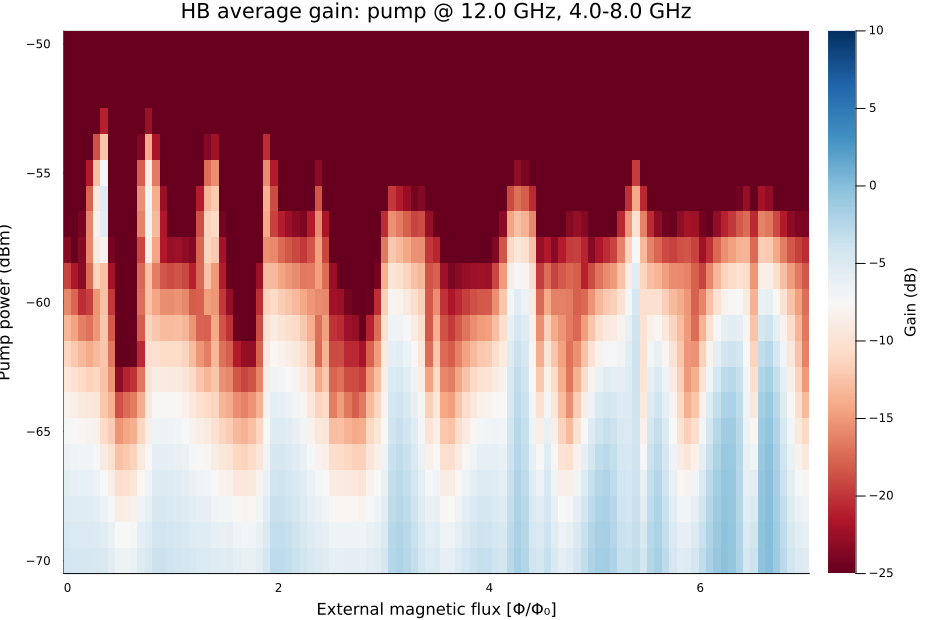

In [105]:
if RUN_GAIN_MAP
    println("\n=== HB flags ===")
    @printf("HB_USE_ZPROP_PUMP      = %s\n", string(HB_USE_ZPROP_PUMP))
    @printf("HB_USE_NL_PUMP_PROP    = %s\n", string(HB_USE_NL_PUMP_PROP))
    @printf("HB_USE_PUMP_DEPLETION   = %s\n", string(HB_USE_PUMP_DEPLETION))
    @printf("HB_USE_HARMONIC_LEAKAGE = %s\n", string(HB_USE_HARMONIC_LEAKAGE))
    @printf("HB_USE_NL_SELECTIVE_LOSS= %s\n", string(HB_USE_NL_SELECTIVE_LOSS))
    gain_map_dB, _ = compute_hb_gain_map(gain_map_flux_scan, pump_power_scan_dBm, gain_map_signal_freqs, pump_frequency_for_gain_map, lookup, device)
    if any(.!isnan.(gain_map_dB))
        idx = argmax(replace(gain_map_dB, NaN => -Inf))
        best = CartesianIndices(gain_map_dB)[idx]
        println("\n=== Best HB gain point ===")
        @printf("External flux = %.4f Phi/Phi0\n", gain_map_flux_scan[best[2]])
        @printf("Pump power    = %.3f dBm\n", pump_power_scan_dBm[best[1]])
        @printf("Gain          = %.3f dB\n", gain_map_dB[best])
    end
    plot_gain_map(gain_map_flux_scan, pump_power_scan_dBm, gain_map_dB, pump_frequency_for_gain_map, gain_map_signal_freqs)
end

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter C:\Users\kiril\.julia\packages\ProgressMeter\N660J\src\ProgressMeter.jl:607
S21 map 100%|██████████████████████████████| Time: 0:00:31 (31.45 ms/it)
   flux: 7.0000


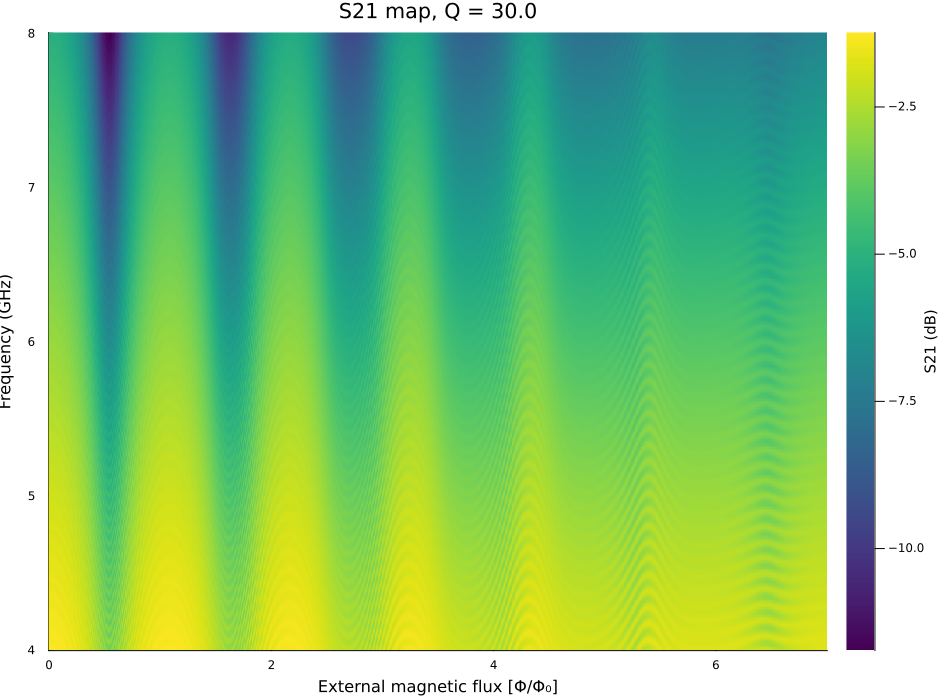

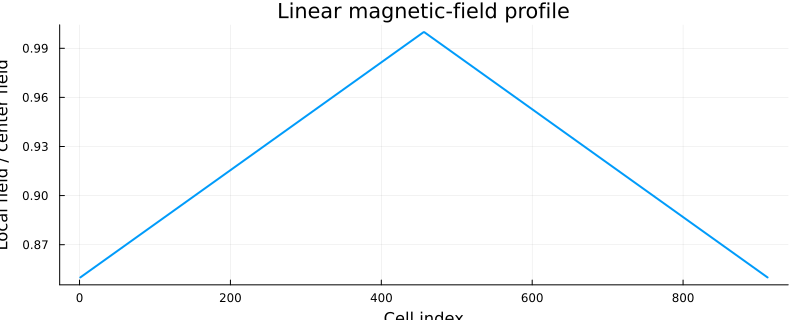

In [13]:
if RUN_S21_MAP
    S21, S21_dB, s21_states = compute_s21_map(flux_center_frustration, freq_array, lookup, device)
    plot_s21_map(flux_center_frustration, freq_array, S21_dB, s21_states[1].local_scale)
end


=== Time-domain spot checks ===
Signal frequency = 6.000 GHz
Pump frequency   = 12.000 GHz
Pump power       = -60.00 dBm
Signal amplitude = 0.0500 μV peak
Measurement mode = fftbin
Linear loss      = ON, CELL_QI = 30.0

phi_dc / Phi0 = 0.4200


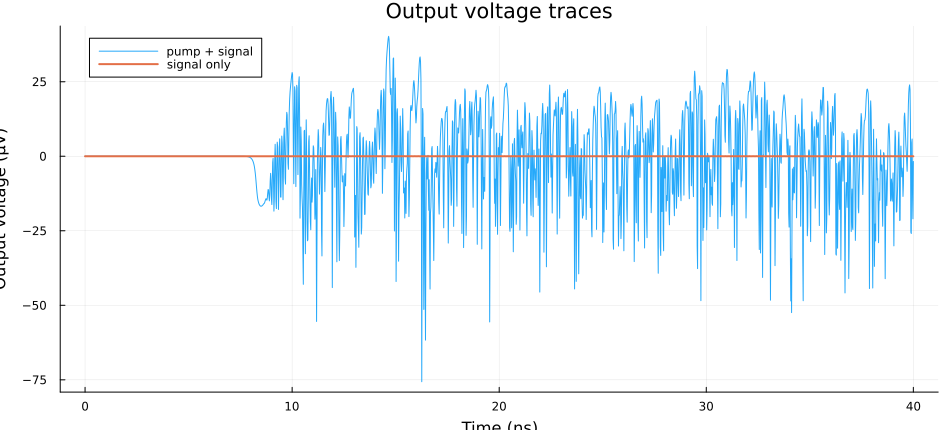

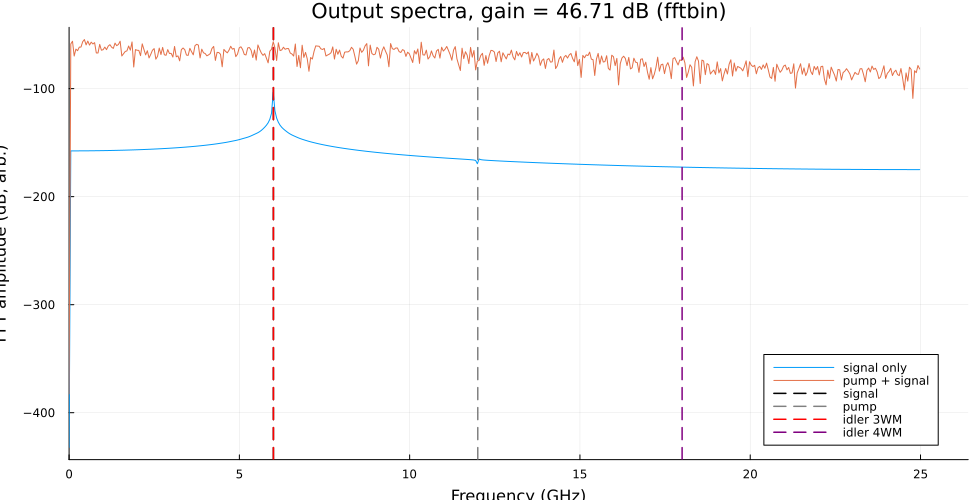

In [14]:
if RUN_TIME_DOMAIN_TWPA
    println("\n=== Time-domain spot checks ===")
    @printf("Signal frequency = %.3f GHz\n", signal_frequency / 1e9)
    @printf("Pump frequency   = %.3f GHz\n", pump_frequency / 1e9)
    @printf("Pump power       = %.2f dBm\n", pump_power_dBm)
    @printf("Signal amplitude = %.4f μV peak\n", signal_amplitude_uV)
    @printf("Measurement mode = %s\n", string(TD_MEASURE_MODE))
    @printf("Linear loss      = %s", USE_DISSIPATION ? "ON" : "OFF")
    USE_DISSIPATION && @printf(", CELL_QI = %.1f\n", CELL_QI)
    !USE_DISSIPATION && println()
    for phi_dc in time_domain_fluxes
        println()
        @printf("phi_dc / Phi0 = %.4f\n", phi_dc)
        plot_single_tone_result(run_single_tone_point(phi_dc, lookup, cap_factor, device))
    end
end